# 1D Cosine Potential and Band-Gap Opening

In the previous notebook, the particle was free. The Hamiltonian contained only the kinetic-energy operator,

$$
H(k)
=
-\frac{\hbar^2}{2m}L(k)
$$

where $L(k)$ is the Bloch finite-difference Laplacian.

That problem produced folded free-particle branches,

$$
E_\ell(k)
=
\frac{\hbar^2}{2m}
\left(k+\frac{2\pi \ell}{a}\right)^2
$$

but those branches were not material bands yet. They were the free-particle parabola viewed in a periodic representation.

Now we add a periodic potential,

$$
V(x+a)=V(x)
$$

The simplest useful choice is a cosine potential,

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

where $a$ is the unit-cell length and $V_0$ controls the strength of the periodic potential.

The Bloch Hamiltonian becomes

$$
H(k)
=
-\frac{\hbar^2}{2m}L(k)
+
V
$$

where $V$ is a diagonal matrix in the real-space grid representation.

This is now a real band-structure problem. The potential is periodic, so it can scatter a state with wave vector $q$ into states whose wave vectors differ by reciprocal lattice vectors,

$$
q'
=
q+G
$$

where

$$
G
=
\frac{2\pi \ell}{a}
$$

For the cosine potential,

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

the only nonzero Fourier components are at

$$
G=\pm\frac{2\pi}{a}
$$

so the potential directly couples wave components separated by $\pm 2\pi/a$.

At the Brillouin-zone boundary, two folded free-particle branches become degenerate. The periodic potential couples those degenerate states and splits their energies. This splitting is the band gap.

In [3]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Physical constants
hbar = 1.055e-34   # [J s]
m_e  = 9.109e-31   # [kg]
eV   = 1.602e-19   # [J]


def build_bloch_laplacian_1d(
    N: int,
    dx: float,
    k: float,
) -> sp.csr_matrix:
    """
    Construct the 1D finite-difference Laplacian on one cell
    with Bloch boundary conditions.

    The Bloch condition is

        psi(x + a) = exp(i k a) psi(x)

    where

        a = N dx
    """

    a = N * dx

    main = -2.0 * np.ones(N)
    off = np.ones(N - 1)

    L = sp.diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        format="lil",
        dtype=complex,
    )

    L[0, -1] = np.exp(-1j * k * a)
    L[-1, 0] = np.exp(1j * k * a)

    return L.tocsr() / dx**2


def build_cosine_potential_1d(
    N: int,
    dx: float,
    V0_eV: float,
) -> sp.csr_matrix:
    """
    Construct the real-space diagonal potential

        V(x) = V0 cos(2 pi x / a)

    where V0 is supplied in eV.
    """

    a = N * dx
    x = np.arange(N) * dx

    V = V0_eV * eV * np.cos(
        2.0 * np.pi * x / a
    )

    return sp.diags(
        V,
        offsets=0,
        format="csr",
        dtype=complex,
    )


def build_bloch_hamiltonian_1d_cosine(
    N: int,
    dx: float,
    k: float,
    V0_eV: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> sp.csr_matrix:
    """
    Construct the 1D Bloch Hamiltonian

        H(k) = T(k) + V

    with

        T(k) = -(hbar^2 / 2m) L(k)

    and

        V(x) = V0 cos(2 pi x / a)
    """

    L_k = build_bloch_laplacian_1d(
        N=N,
        dx=dx,
        k=k,
    )

    T_k = -(hbar**2 / (2.0 * mass)) * L_k

    V = build_cosine_potential_1d(
        N=N,
        dx=dx,
        V0_eV=V0_eV,
    )

    return T_k + V

## Computing the Cosine-Potential Bands

For the free-particle notebook, it was better to label curves by the reciprocal-lattice branch index $\ell$.

That changes here.

Once the cosine potential is added, the free-particle branches are no longer independent. The periodic potential mixes them. Therefore, the eigenvalues of $H(k)$ are now the useful band labels.

For each $k$, we solve

$$
H(k)\psi_{n,k}
=
E_n(k)\psi_{n,k}
$$

and sort the eigenvalues in ascending energy,

$$
E_1(k) \leq E_2(k) \leq E_3(k) \leq \cdots
$$

This sorted spectrum is now physically meaningful because the potential has turned the folded free-particle branches into interacting bands.

In [4]:
def calculate_cosine_bands(
    k_vals: np.ndarray,
    N_bands: int,
    N: int,
    dx: float,
    V0_eV: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Compute the lowest N_bands eigenvalues of the cosine-potential
    Bloch Hamiltonian for each k.
    """

    E_k = []

    for k in k_vals:
        H_k = build_bloch_hamiltonian_1d_cosine(
            N=N,
            dx=dx,
            k=k,
            V0_eV=V0_eV,
            mass=mass,
            hbar=hbar,
        )

        eigvals = np.linalg.eigvalsh(H_k.toarray())
        E_k.append(eigvals[:N_bands])

    return np.array(E_k)


def folded_free_particle_energy_fd(
    k_vals: np.ndarray,
    ell_vals: np.ndarray,
    a: float,
    dx: float,
    mass: float = m_e,
    hbar: float = hbar,
) -> np.ndarray:
    """
    Finite-difference folded free-particle energies:

        E_l(k) = (hbar^2 / 2m) (4 / dx^2) sin^2(q dx / 2)

    where

        q = k + G_l
    """

    E = []

    for ell in ell_vals:
        G = 2.0 * np.pi * ell / a
        q = k_vals + G

        E_ell = (
            hbar**2
            / (2.0 * mass)
            * (4.0 / dx**2)
            * np.sin(0.5 * q * dx)**2
        )

        E.append(E_ell)

    return np.array(E).T

## Plotting the Bands

The dashed curves below are the folded free-particle branches. The solid curves are the eigenvalues of the cosine-potential Hamiltonian.

The point of this plot is to show what the potential does to the free-particle folding picture. Away from degeneracies, the cosine-potential bands mostly follow the free-particle branches. Near degeneracies, the potential mixes the branches and opens gaps.

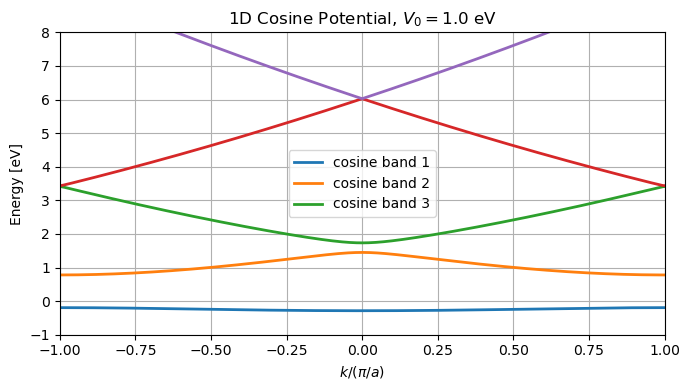

In [6]:
# Parameters

N_uc = 64
L_uc = 1e-9
dx = L_uc / N_uc
a = L_uc

N_bands = 5
V0_eV = 1.0

k_vals = np.linspace(
    -np.pi / a,
     np.pi / a,
    500,
)

k_vals_pi = k_vals * a / np.pi

ell_vals = np.array([-2, -1, 0, 1, 2])


# Free finite-difference folded branches

Ek_free_fd_eV = folded_free_particle_energy_fd(
    k_vals=k_vals,
    ell_vals=ell_vals,
    a=a,
    dx=dx,
) / eV


# Cosine-potential bands

Ek_cos_eV = calculate_cosine_bands(
    k_vals=k_vals,
    N_bands=N_bands,
    N=N_uc,
    dx=dx,
    V0_eV=V0_eV,
) / eV


# Plot

plt.figure(figsize=(7, 4))

if False:
  for j, ell in enumerate(ell_vals):
      plt.plot(
          k_vals_pi,
          Ek_free_fd_eV[:, j],
          linestyle="--",
          linewidth=1,
          alpha=0.6,
          label=rf"free $\ell={ell}$" if ell in [-1, 0, 1] else None,
      )

for n in range(N_bands):
    plt.plot(
        k_vals_pi,
        Ek_cos_eV[:, n],
        linewidth=2,
        label=f"cosine band {n + 1}" if n < 3 else None,
    )

plt.xlim([-1, 1])
plt.ylim([-1, 8])
plt.xlabel(r"$k/(\pi/a)$")
plt.ylabel("Energy [eV]")
plt.title(rf"1D Cosine Potential, $V_0={V0_eV}$ eV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## The First Band Gap

The first band gap opens at the Brillouin-zone boundary,

$$
k=\pm\frac{\pi}{a}
$$

At this point, the free-particle branches with wave vectors related by a reciprocal lattice vector become degenerate. The cosine potential couples those branches and splits the degeneracy.

For

$$
V(x)
=
V_0\cos\left(\frac{2\pi x}{a}\right)
$$

the Fourier coefficients are

$$
V_{\pm 1}
=
\frac{V_0}{2}
$$

In the nearly-free-electron approximation, the first zone-boundary gap is approximately

$$
\Delta E
\approx
2|V_1|
=
V_0
$$